# Forecast with known-future exogenous variables

Use **`df`** for history (`unique_id`, `ds`, `y`, and exog columns in the past) and **`X_df`** for
known-future exog over the next `h` steps (no `y`). See [Exogenous variables](../exogenous-variables.md)
for the full API.

**Dataset:** panel built from fev-bench `epf_*` markets (BE, DE, FR, NP, PJM) with two covariates
per market, unified as `ex_1` and `ex_2`.

**Models:** **Chronos-2**, **TimesFM 3.0**, and **T0** use native exog; **`Tafsut-no-exog`** sets
`exog_strategy=False` so a mixed `FoundationForecast` can pass `X_df` without error. Native models
support **`level`** with exog.

## Import libraries

In [1]:
import pandas as pd

from foundationforecast import FoundationForecast

/Users/azul/projects/foundationforecast/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:datasets:JAX version 0.7.1 available.


## Load the dataset

- **`train.parquet`:** history with `y`, `ex_1`, and `ex_2`
- **`test.parquet`:** 24-hour horizon with exog (and `y` for evaluation)

For cross-validation we concatenate train and test so the last `h` steps match the fev-bench holdout.
`X_df` carries horizon exog only.

In [2]:
df = pd.read_parquet("https://timecopilot.s3.amazonaws.com/public/data/electricity_price/train.parquet") 
X_df = pd.read_parquet("https://timecopilot.s3.amazonaws.com/public/data/electricity_price/test.parquet")
y_test_df = X_df[["unique_id", "ds", "y"]]
X_df = X_df.drop(columns=["y"])

df.head()

,unique_id,ds,y,ex_1,ex_2
0,BE,2011-01-09 00:00:00,32.540001,63065.0,63000.0
1,BE,2011-01-09 01:00:00,21.549999,62715.0,58800.0
2,BE,2011-01-09 02:00:00,15.710000,61952.0,58500.0
3,BE,2011-01-09 03:00:00,10.580000,59262.0,54300.0
4,BE,2011-01-09 04:00:00,10.320000,56883.0,51900.0


In [3]:
X_df.head()

,unique_id,ds,ex_1,ex_2
0,BE,2016-12-12 00:00:00,56275.0,64188.0
1,BE,2016-12-12 01:00:00,54866.0,61076.0
2,BE,2016-12-12 02:00:00,56534.0,61246.0
3,BE,2016-12-12 03:00:00,56042.0,58082.0
4,BE,2016-12-12 04:00:00,56114.0,56397.0


In [4]:
y_test_df.head()

,unique_id,ds,y
0,BE,2016-12-12 00:00:00,35.099998
1,BE,2016-12-12 01:00:00,30.440001
2,BE,2016-12-12 02:00:00,35.099998
3,BE,2016-12-12 03:00:00,35.099998
4,BE,2016-12-12 04:00:00,33.020000


## Plot the data

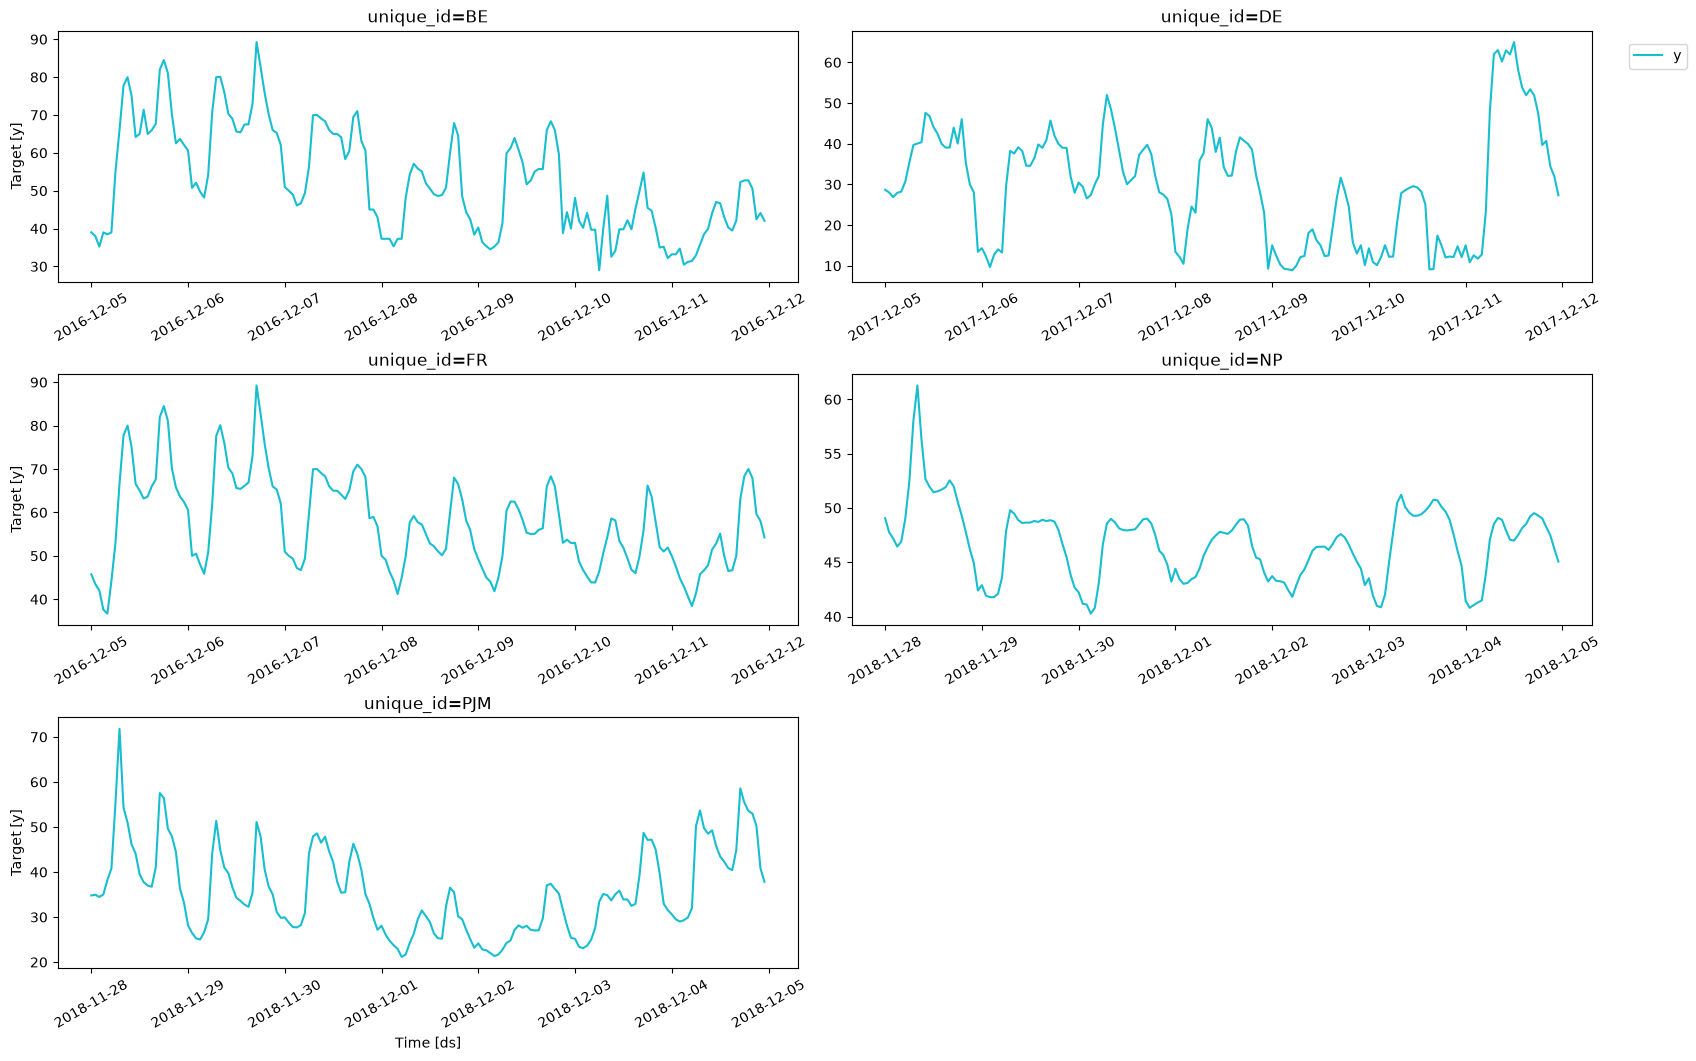

In [5]:
FoundationForecast.plot(df, max_insample_length=24 * 7)

## Import the models

In [6]:
from foundationforecast.models import Chronos, T0, Tafsut, TimesFM, TiRex

## Create a FoundationForecast

In [7]:
models = [
    Tafsut(alias="Tafsut-no-exog", exog_strategy=False),
    TimesFM(repo_id="google/timesfm-3.0-pytorch", alias="TimesFM-3"),
    T0(repo_id="theforecastingcompany/t0-beta", alias="t0-beta"),
    #TiRex(repo_id="NX-AI/TiRex-2", alias="TiRex-2"),
    Chronos(repo_id="amazon/chronos-2", alias="Chronos-2"),
    Chronos(repo_id="amazon/chronos-2", alias="Chronos-2-no-exog", exog_strategy=False),
]

ff = FoundationForecast(models=models)

In [8]:
fcst_df = ff.forecast(df, h=24, X_df=X_df, level=[80, 90])

100%|██████████| 1/1 [00:01<00:00,  1.01s/it]


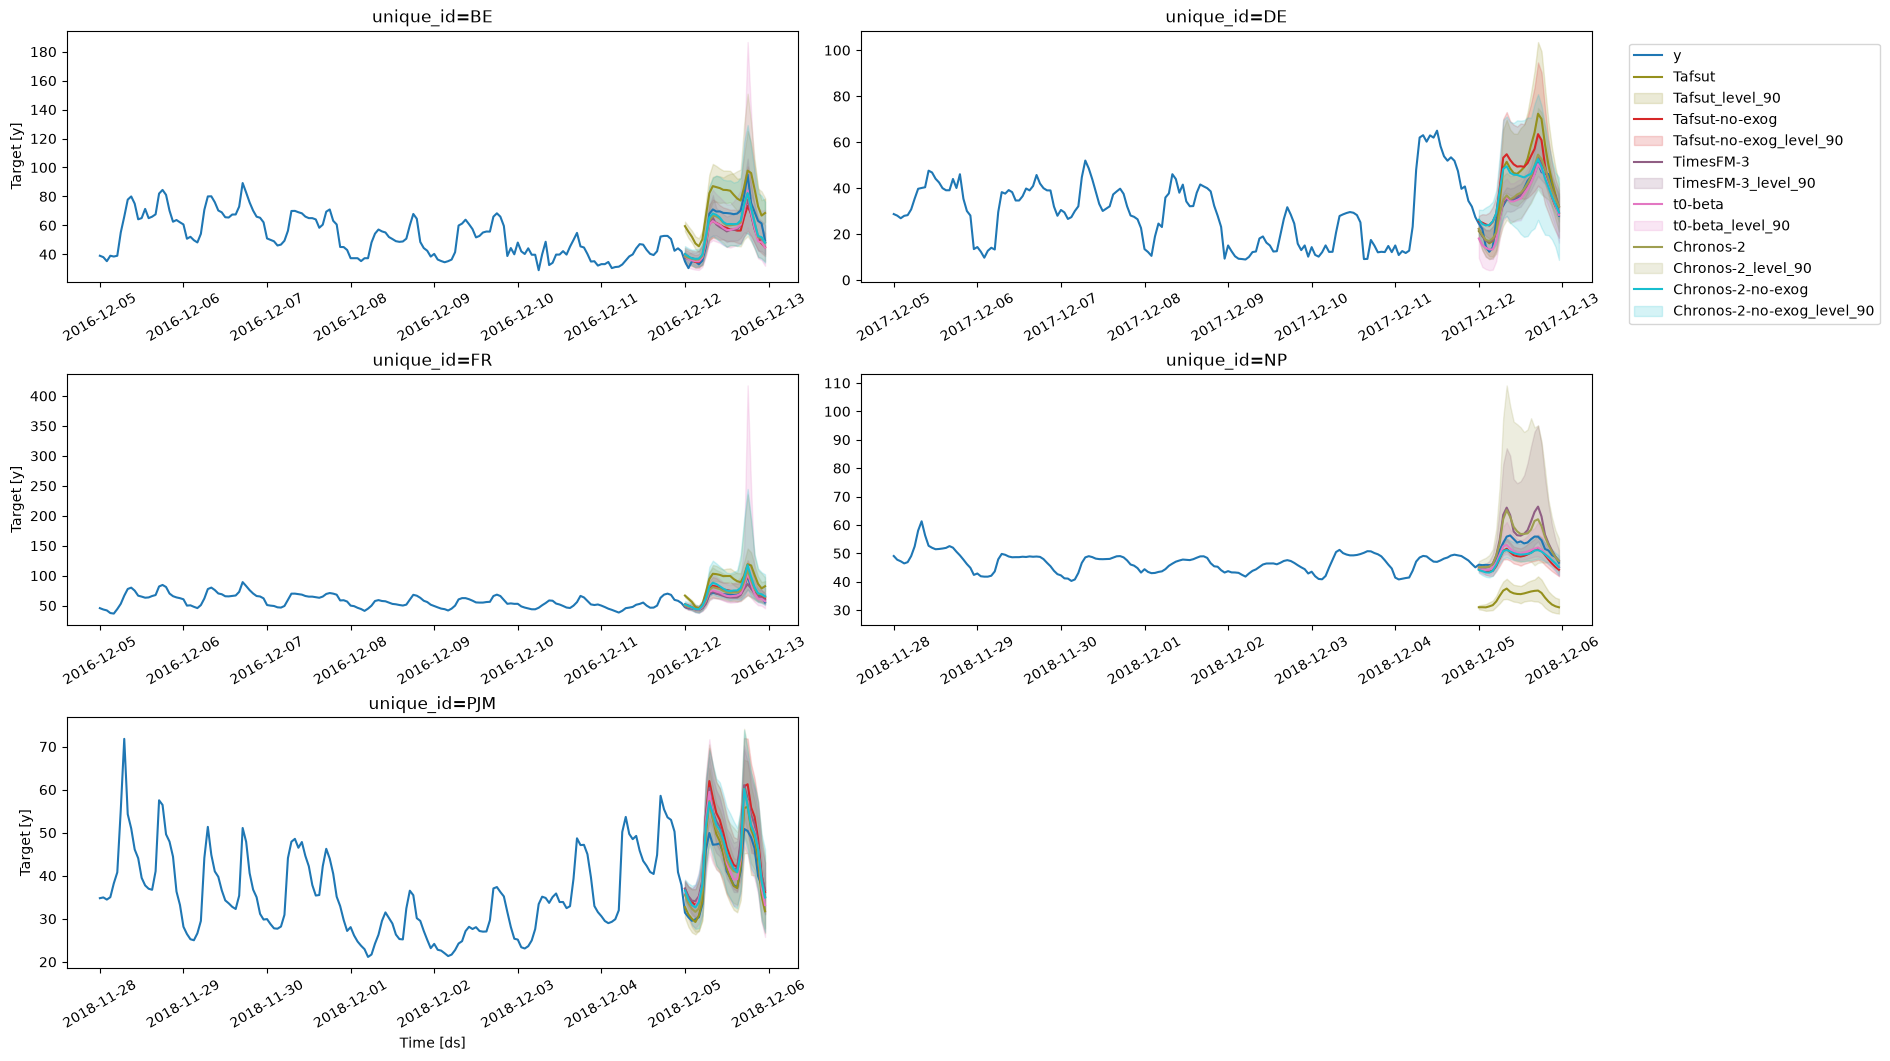

In [9]:
ff.plot(df, fcst_df.merge(y_test_df, on=["unique_id", "ds"]), max_insample_length=24 * 7, level=[90])

In [ ]:
level = [80, 90]
h = 24

cv_df = ff.cross_validation(
    df=df,
    h=h,
    freq="h",
    level=level,
    n_windows=1,
)

100%|██████████| 1/1 [00:01<00:00,  2.00s/it]
1it [00:03,  3.26s/it]
100%|██████████| 1/1 [00:01<00:00,  1.90s/it]
1it [00:01,  1.94s/it]
0it [00:00, ?it/s]

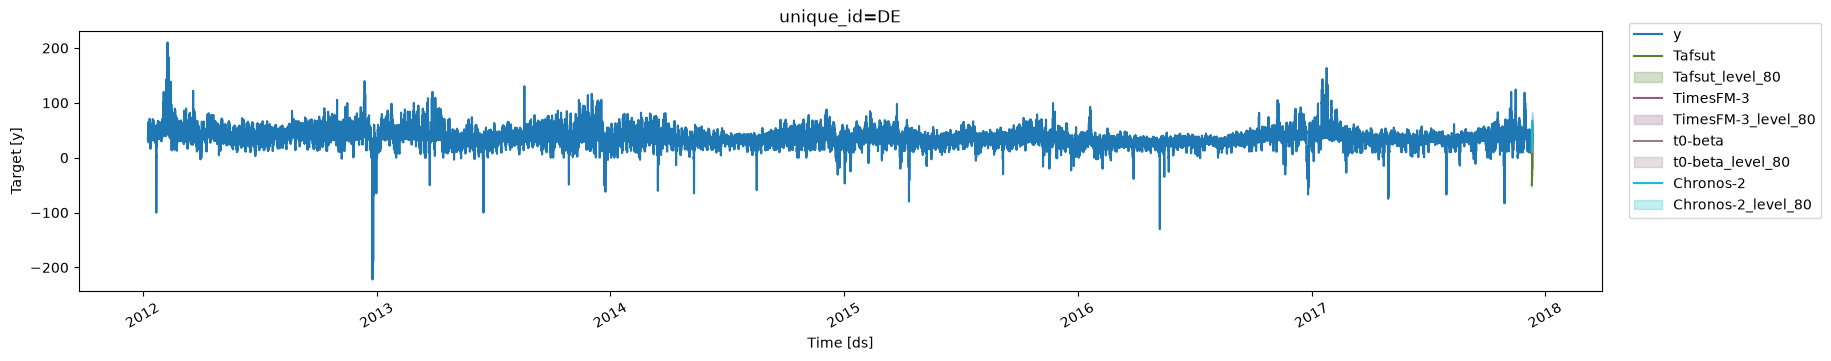

In [11]:
ff.plot(
    df.query("unique_id == 'DE'"),
    cv_df.query("unique_id == 'DE'").drop(columns=["cutoff", "y"]),
    level=[80],
)

In [12]:
cv_df.head()

,unique_id,ds,cutoff,y,Tafsut,Tafsut-lo-80,Tafsut-hi-80,Tafsut-lo-90,Tafsut-hi-90,TimesFM-3,...,t0-beta,t0-beta-lo-80,t0-beta-hi-80,t0-beta-lo-90,t0-beta-hi-90,Chronos-2,Chronos-2-lo-80,Chronos-2-hi-80,Chronos-2-lo-90,Chronos-2-hi-90
0,BE,2016-12-11 00:00:00,2016-12-10 23:00:00,33.200001,-4.157150,-7.775020,-0.278030,-7.775020,-0.278030,31.545292,...,32.794159,28.206137,37.577183,26.611589,39.489433,32.425201,28.058277,36.865078,26.096519,38.751842
1,BE,2016-12-11 01:00:00,2016-12-10 23:00:00,33.200001,-7.703335,-12.318710,-2.329693,-12.318710,-2.329693,30.904312,...,31.856348,26.989683,37.159348,25.173197,39.106892,31.214901,26.553318,35.934124,24.536396,37.829185
2,BE,2016-12-11 02:00:00,2016-12-10 23:00:00,34.700001,-9.238571,-14.005993,-3.258373,-14.005993,-3.258373,30.139259,...,31.114357,25.701694,36.754765,23.833679,38.723789,30.686020,25.748207,35.666660,23.632435,37.629265
3,BE,2016-12-11 03:00:00,2016-12-10 23:00:00,30.459999,-13.288357,-18.311528,-7.289814,-18.311528,-7.289814,28.346500,...,30.010242,24.344576,36.333527,22.316057,38.408302,29.452126,23.877048,34.600399,21.456821,36.538319
4,BE,2016-12-11 04:00:00,2016-12-10 23:00:00,31.200001,-16.328477,-21.661463,-10.276570,-21.661463,-10.276570,27.079426,...,28.197548,22.208286,34.678421,20.190699,36.671597,26.980789,20.742443,32.536556,18.127014,34.714508


## Evaluation

In [13]:
from functools import partial

from utilsforecast.evaluation import evaluate
from utilsforecast.losses import mase, scaled_crps

In [14]:
eval_df = evaluate(
    cv_df.drop(columns=["cutoff"]),
    train_df=df,
    metrics=[partial(mase, seasonality=24), scaled_crps],
    level=level,
)
eval_df.groupby("metric").mean(numeric_only=True).T.round(3)

metric,mase,scaled_crps
Tafsut,6.365,0.685
TimesFM-3,0.588,0.030
t0-beta,0.571,0.028
Chronos-2,0.691,0.031
